# Explore here

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
df = pd.read_csv(url, sep=';')

print(df.head())
print(df.info())


   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [15]:
df = df.drop_duplicates()

df = df.drop(columns=['duration'])

df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_final.drop('y', axis=1)
y = df_final['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Matriz de Confusión:
 [[7167   98]
 [ 766  205]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      7265
           1       0.68      0.21      0.32       971

    accuracy                           0.90      8236
   macro avg       0.79      0.60      0.63      8236
weighted avg       0.88      0.90      0.87      8236

Accuracy: 0.8951


In [17]:
from sklearn.model_selection import GridSearchCV

model_opt = LogisticRegression(class_weight='balanced', max_iter=1000)

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

grid_search = GridSearchCV(model_opt, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test_scaled)

print("Mejores parámetros:", grid_search.best_params_)
print("\nReporte de Clasificación Optimizado:\n", classification_report(y_test, y_pred_opt))

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

Mejores parámetros: {'C': 10, 'penalty': 'l2'}

Reporte de Clasificación Optimizado:
               precision    recall  f1-score   support

           0       0.94      0.85      0.89      7265
           1       0.36      0.63      0.46       971

    accuracy                           0.82      8236
   macro avg       0.65      0.74      0.68      8236
weighted avg       0.88      0.82      0.84      8236



/tmp/ipykernel_7123/663878236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='viridis')


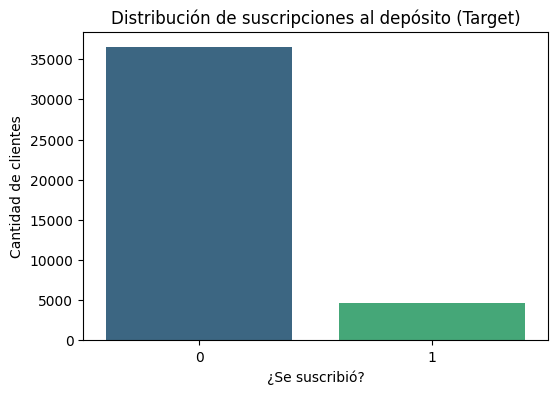

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', palette='viridis')
plt.title('Distribución de suscripciones al depósito (Target)')
plt.xlabel('¿Se suscribió?')
plt.ylabel('Cantidad de clientes')
plt.show()

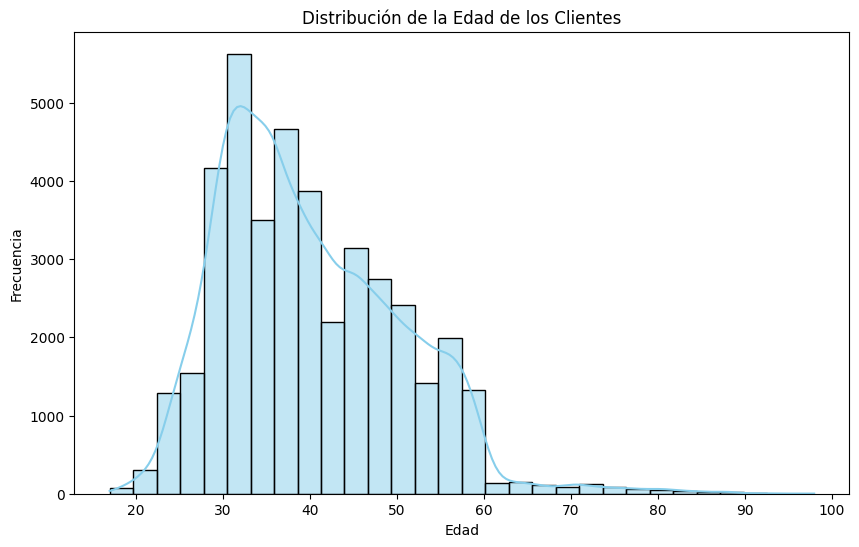

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de la Edad de los Clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

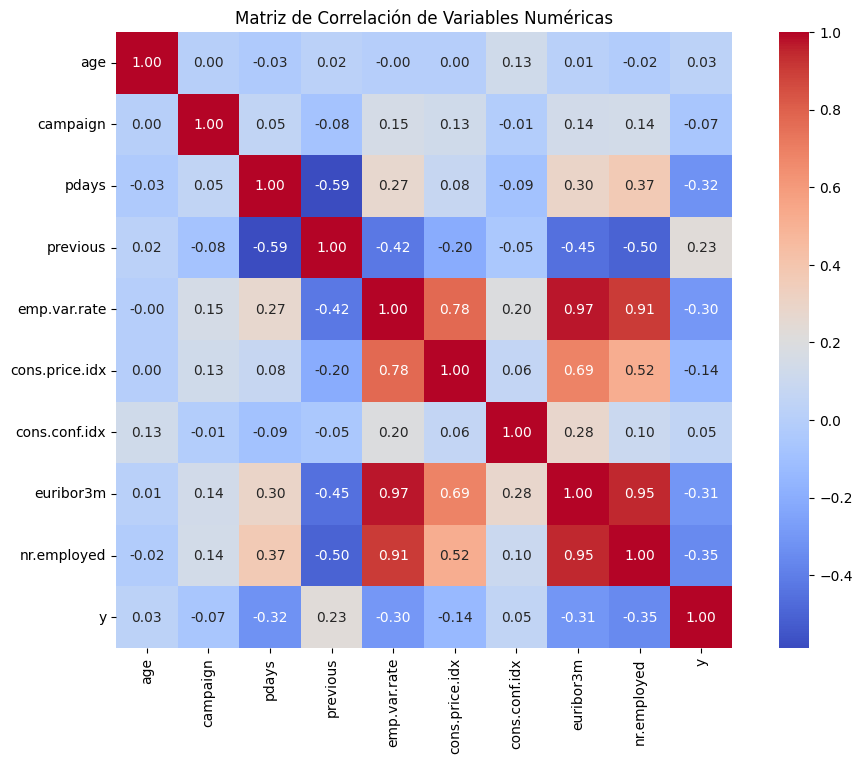

In [20]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

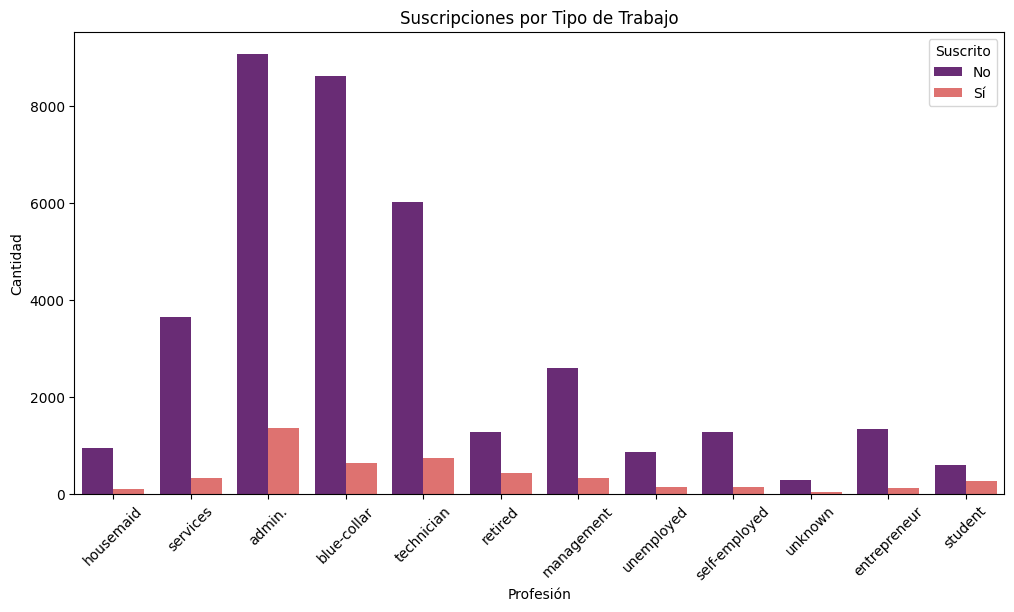

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='job', hue='y', palette='magma')
plt.title('Suscripciones por Tipo de Trabajo')
plt.xticks(rotation=45)
plt.xlabel('Profesión')
plt.ylabel('Cantidad')
plt.legend(title='Suscrito', labels=['No', 'Sí'])
plt.show()

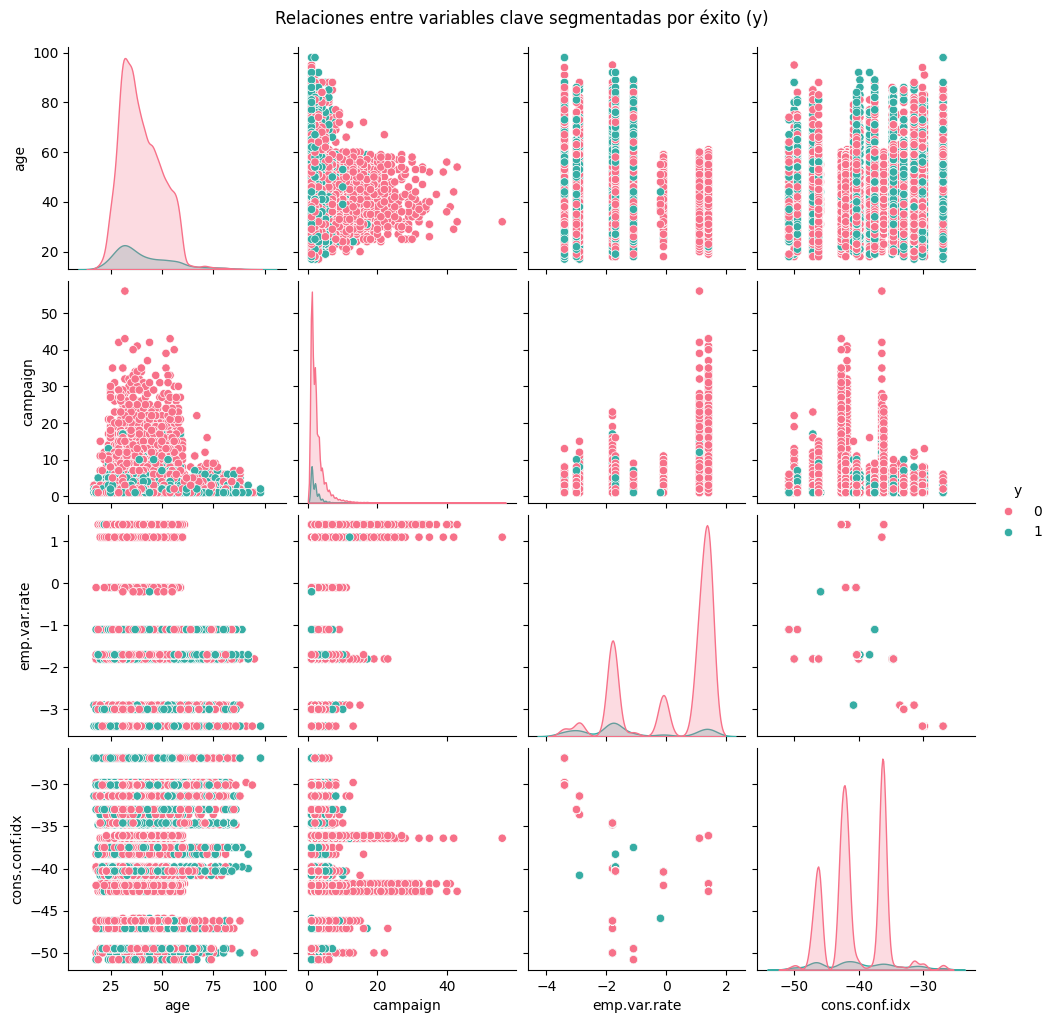

In [22]:
subset_cols = ['age', 'campaign', 'emp.var.rate', 'cons.conf.idx', 'y']

sns.pairplot(df[subset_cols], hue='y', palette='husl', diag_kind='kde')
plt.suptitle('Relaciones entre variables clave segmentadas por éxito (y)', y=1.02)
plt.show()